<a href="https://colab.research.google.com/github/IMPERIUMSIXTH/JupyterNotebooks/blob/main/Machine_1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scienceplots
!pip install celluloid
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from IPython.display import display, Latex, Image
from celluloid import Camera

np.random.seed(0)
plt.style.use(["science", "no-latex"])

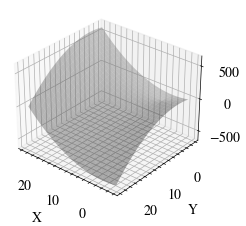

In [3]:
def surface_fn(X, Y):
    return X**2 - Y**2


def generate_function(dims, surface_fn):
    x = np.linspace(-5, 25, dims)
    y = np.linspace(-5, 25, dims)
    X, Y = np.meshgrid(x, y)
    Z = surface_fn(X, Y)

    return X, Y, Z


dims = 25
X, Y, Z = generate_function(dims, surface_fn)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.view_init(30, 130)

ax.plot_surface(X, Y, Z, color="grey", alpha=0.4)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

In [4]:
def surface_gradient(pt):
    x, y = pt
    return np.array([2 * x, -2 * y])


class SGD:
    def __init__(self, learning_rate):
        self.learning_rate = learning_rate

    def step(self, params, gradient):
        return params - self.learning_rate * gradient


class RMSprop:
    def __init__(self, learning_rate, beta=0.99, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta = beta
        self.epsilon = epsilon
        self.s = 0

    def step(self, params, gradient):
        self.s = self.beta * self.s + (1 - self.beta) * gradient**2
        return params - self.learning_rate * gradient / (np.sqrt(self.s) + self.epsilon)


class Adam:
    def __init__(self, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = 0
        self.v = 0
        self.t = 0

    def step(self, params, gradient):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradient
        self.v = self.beta2 * self.v + (1 - self.beta2) * gradient**2
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return params - self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)

In [5]:
def create_scatter_and_3d_plot():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Optimizers")

    ylim = (-5, 25)
    zlim = (-650, 550)

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Z", fontweight="normal")
    ax[0].set_title("Z Value")
    ax[0].set_ylim((-650, 450))

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Current Position")
    ax[2].view_init(30, 130)
    ax[2].set_xlim(ylim)
    ax[2].set_ylim(ylim)
    ax[2].set_zlim(zlim)

    camera = Camera(fig)
    return ax[0], ax[2], camera


def show_epoch(epoch):
    return (
        (epoch < 25 and epoch % 2 == 0)
        or (epoch < 50 and epoch % 5 == 0)
        or (epoch <= 100 and epoch % 15 == 0)
        or (epoch <= 500 and epoch % 45 == 0)
        or (epoch <= 1000 and epoch % 50 == 0)
        or epoch % 250 == 0
    )

In [6]:
def fit(optimizers, surface_fn, X, Y, Z, initial_pt, epochs, output_filename, colors):
    optimizer_names = list(optimizers.keys())
    points = [initial_pt.copy() for _ in optimizers]

    z_idx = np.arange(1, epochs + 1)
    z_vals = [np.full(epochs, -1.0) for _ in range(len(optimizer_names))]

    z_ax, predictions_ax, camera = create_scatter_and_3d_plot()

    for idx in range(epochs):
        prediction_legends = []
        z_legends = []

        for opt_idx, optimizer in enumerate(optimizers.values()):
            pt = points[opt_idx]
            z = surface_fn(pt[0], pt[1])
            gradient = surface_gradient(pt)
            points[opt_idx] = optimizer.step(pt, gradient)

            if show_epoch(idx):
                z_clamped = np.maximum(-1000, z)

                prediction_legend = predictions_ax.scatter(
                    pt[0], pt[1], z_clamped, color=colors[opt_idx]
                )
                prediction_legends.append(prediction_legend)

                z_vals[opt_idx][idx] = z_clamped
                visible = z_vals[opt_idx] != -1
                z_legend = z_ax.plot(
                    z_idx[visible][: idx + 1],
                    z_vals[opt_idx][visible][: idx + 1],
                    color=colors[opt_idx],
                    alpha=0.5,
                )
                z_legends.append(z_legend[0])

        if show_epoch(idx):
            predictions_ax.plot_surface(X, Y, Z, color="grey", alpha=0.3)
            predictions_ax.legend(prediction_legends, optimizer_names, loc="upper right")
            z_ax.legend(z_legends, optimizer_names, loc="upper right")
            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

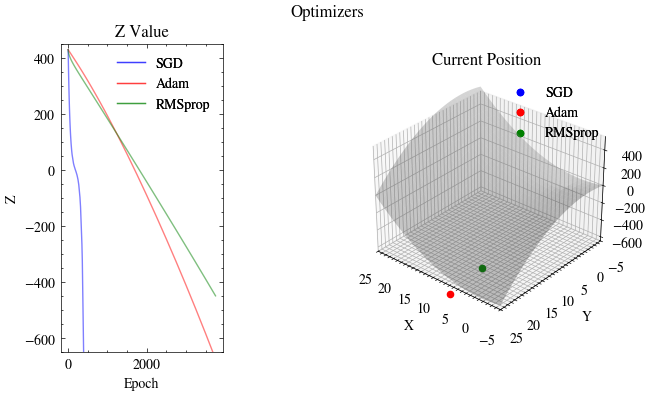

In [7]:
initial_pt = np.array([20.75, 0.5])

learning_rate = 0.005
epochs = 4000

optimizers = {
    "SGD": SGD(learning_rate),
    "Adam": Adam(learning_rate),
    "RMSprop": RMSprop(learning_rate),
}
colors = ["blue", "red", "green"]

output_filename = "optimizers.gif"
fit(optimizers, surface_fn, X, Y, Z, initial_pt, epochs, output_filename, colors)

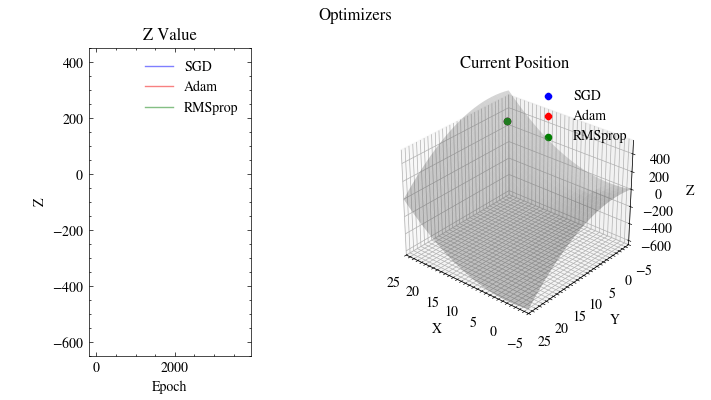

In [8]:
Image(filename=output_filename)

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(0)

In [10]:
class TorchNet(nn.Module):
    def __init__(self, initial_pt):
        super(TorchNet, self).__init__()

        self.pts = torch.nn.Parameter(initial_pt)

    def forward(self, surface_fn):
        return surface_fn(self.pts[0], self.pts[1])

    def get_pts(self):
        return self.pts.detach().cpu().numpy()

In [11]:
def torch_fit(
    optimizer_types, surface_fn, X, Y, Z, epochs, learning_rate, output_filename, colors
):
    torch_models = []
    torch_optimizers = []
    optimizer_names = list(optimizer_types.keys())

    z_idx = np.arange(1, epochs + 1)
    z_vals = [np.full(epochs, -1) for _ in range(len(optimizer_names))]

    for optimizer in optimizer_types.values():
        torch_model = TorchNet(initial_pt_tensor.clone()).to(device)
        torch_optimizer = optimizer(torch_model.parameters(), lr=learning_rate)

        torch_models.append(torch_model)
        torch_optimizers.append(torch_optimizer)

    z_ax, predictions_ax1, camera1 = create_scatter_and_3d_plot()

    for idx in range(epochs):
        predictions_legends = []
        z_legends = []

        for torch_idx, (model, optimizer) in enumerate(
            zip(torch_models, torch_optimizers)
        ):
            loss = model(surface_fn)

            # optimizer
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if show_epoch(idx):
                loss_np = np.maximum(-1000, loss.detach().cpu().numpy())

                model_pts = model.get_pts()
                predictions_legends_idx = predictions_ax1.scatter(
                    model_pts[0], model_pts[1], loss_np, color=colors[torch_idx]
                )
                predictions_legends.append(predictions_legends_idx)

                z_vals[torch_idx][idx] = loss_np
                visible_mse = z_vals[torch_idx] != -1

                z_legends_idx = z_ax.plot(
                    z_idx[visible_mse][: idx + 1],
                    z_vals[torch_idx][visible_mse][: idx + 1],
                    color=colors[torch_idx],
                    alpha=0.5,
                )
                z_legends.append(z_legends_idx[0])

        if show_epoch(idx):
            predictions_ax1.plot_surface(X, Y, Z, color="grey", alpha=0.3)
            predictions_ax1.legend(
                predictions_legends, optimizer_names, loc="upper right"
            )
            z_ax.legend(z_legends, optimizer_names, loc="upper right")

            camera1.snap()

    animation1 = camera1.animate()
    animation1.save(output_filename, writer="pillow")
    plt.show()

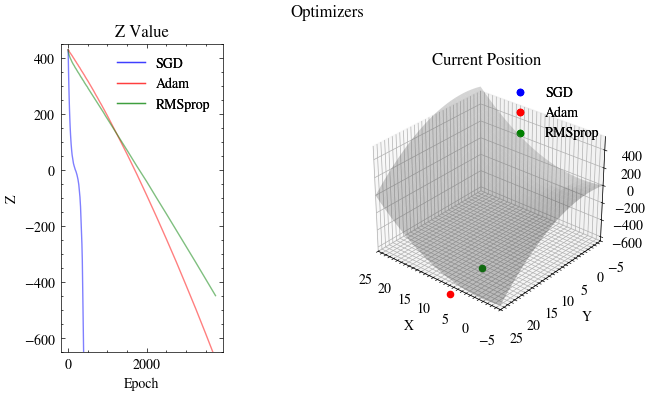

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

initial_pt = np.array([20.75, 0.5])
initial_pt_tensor = torch.tensor(initial_pt, device=device, dtype=torch.float32)

optimizer_types = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "RMSprop": torch.optim.RMSprop,
}
colors = ["blue", "red", "green"]

learning_rate = 0.005
epochs = 4000

output_filename_pytorch = "optimizers_pytorch.gif"
torch_fit(
    optimizer_types,
    surface_fn,
    X,
    Y,
    Z,
    epochs,
    learning_rate,
    output_filename_pytorch,
    colors,
)

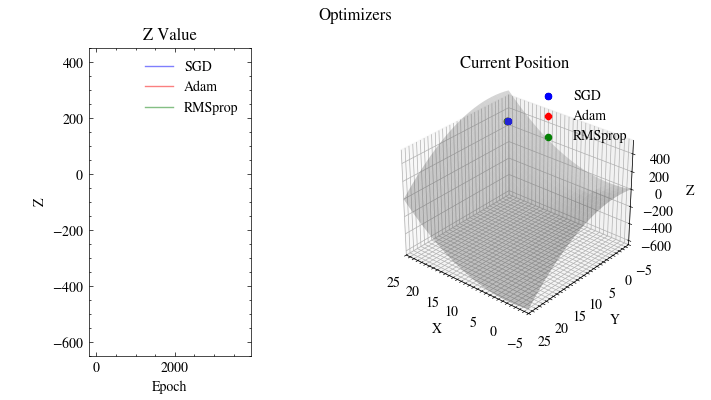

In [13]:
Image(filename=output_filename_pytorch)